In [1]:
# Install Kaggle API if not already installed
!pip install kaggle

# Standard libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [kaggle]━━━━ 4/5 [kaggle]dk]gify]


In [2]:
df = pd.read_csv("/home/kelvin/Assignments/Class Activity And Practicals/Sample Superstore/SampleSuperstore.csv")
df.head()


,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


In [3]:
print(df.columns)


Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')


In [13]:
# Fill missing values with 0 instead of dropping
df.fillna(0, inplace=True)

# Remove duplicates
df.drop_duplicates(inplace=True)

# Standardize column names (remove spaces)
df.columns = df.columns.str.strip()

# Quick check
print(df.isnull().sum())


Ship Mode       0
Segment         0
Country         0
City            0
State           0
Postal Code     0
Region          0
Category        0
Sub-Category    0
Sales           0
Quantity        0
Discount        0
Profit          0
dtype: int64


In [14]:
# Fact table: sales metrics
fact_sales = df[['Sales','Profit','Quantity','Discount','Region','Category','Segment']]

# Customer dimension
customer_dim = df[['Segment','Region','Country','City','State','Postal Code']].drop_duplicates()

# Product dimension
product_dim = df[['Category','Sub-Category']].drop_duplicates()

# Shipping dimension
shipping_dim = df[['Ship Mode']].drop_duplicates()


In [16]:
!pip install graphviz
from graphviz import Digraph


Defaulting to user installation because normal site-packages is not writeable


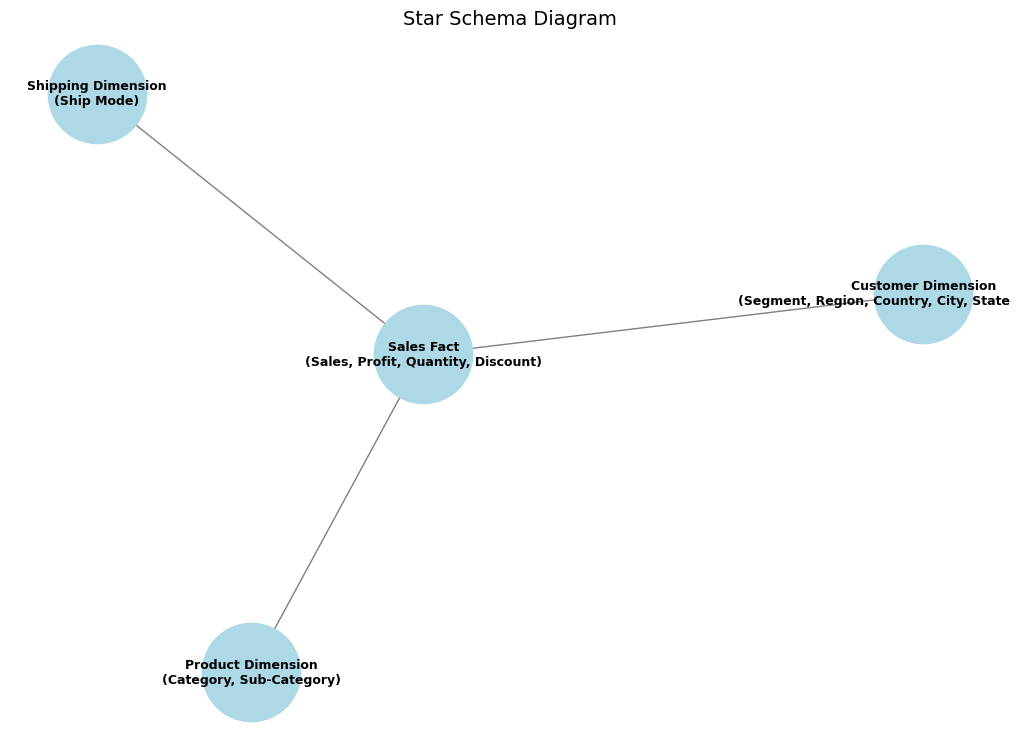

In [22]:
import matplotlib.pyplot as plt
import networkx as nx

# Create a graph
G = nx.Graph()

# Add nodes
G.add_node("Sales Fact\n(Sales, Profit, Quantity, Discount)")
G.add_node("Customer Dimension\n(Segment, Region, Country, City, State, Postal Code)")
G.add_node("Product Dimension\n(Category, Sub-Category)")
G.add_node("Shipping Dimension\n(Ship Mode)")

# Connect dimensions to fact table
G.add_edge("Sales Fact\n(Sales, Profit, Quantity, Discount)",
           "Customer Dimension\n(Segment, Region, Country, City, State, Postal Code)")
G.add_edge("Sales Fact\n(Sales, Profit, Quantity, Discount)",
           "Product Dimension\n(Category, Sub-Category)")
G.add_edge("Sales Fact\n(Sales, Profit, Quantity, Discount)",
           "Shipping Dimension\n(Ship Mode)")

# Draw the graph
plt.figure(figsize=(10,7))
pos = nx.spring_layout(G, seed=42)  # layout for positioning
nx.draw(G, pos, with_labels=True, node_size=5000, node_color="lightblue",
        font_size=9, font_weight="bold", edge_color="gray")
plt.title("Star Schema Diagram", fontsize=14)
plt.show()


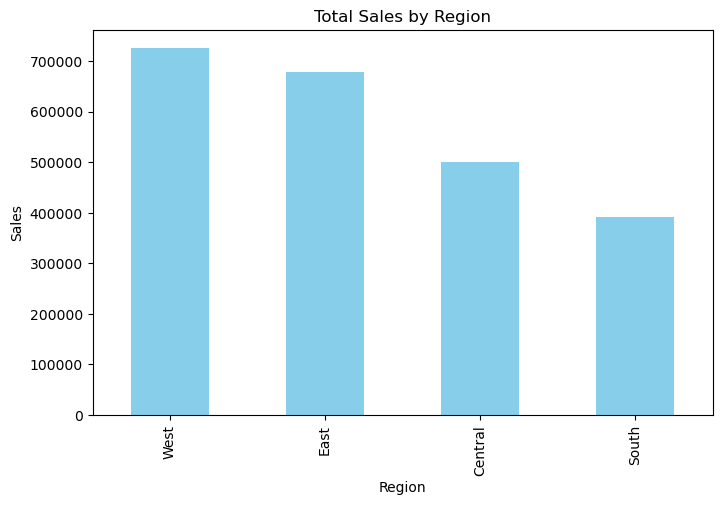

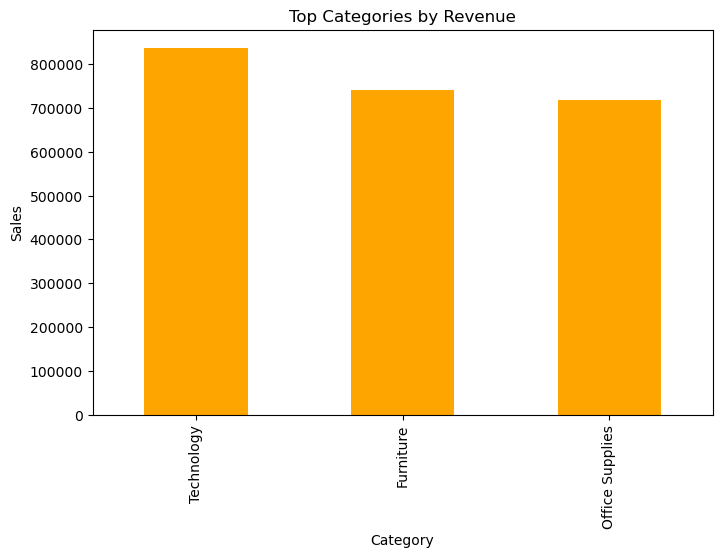

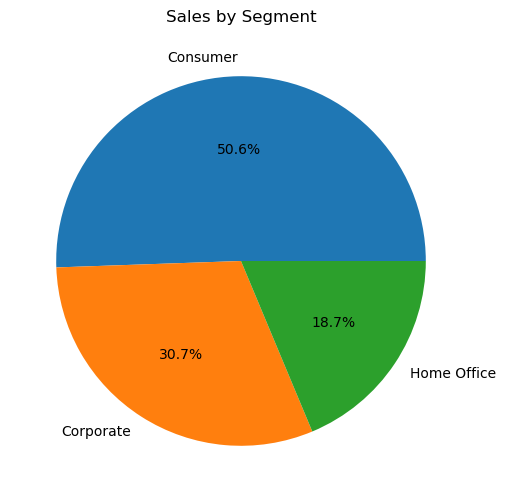

In [23]:
import matplotlib.pyplot as plt

# Total sales by region
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
region_sales.plot(kind='bar', color='skyblue', figsize=(8,5), title="Total Sales by Region")
plt.ylabel("Sales")
plt.show()

# Top categories by revenue
category_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
category_sales.plot(kind='bar', color='orange', figsize=(8,5), title="Top Categories by Revenue")
plt.ylabel("Sales")
plt.show()

# Segment analysis
segment_sales = df.groupby('Segment')['Sales'].sum()
segment_sales.plot(kind='pie', autopct='%1.1f%%', figsize=(6,6), title="Sales by Segment")
plt.ylabel("")
plt.show()


In [25]:
# 1. Customer Segment column already exists: 'Segment'

# 2. Modify ETL to fill missing values instead of dropping
df.fillna(0, inplace=True)

# 3. New query: Top region by sales
top_region = df.groupby('Region')['Sales'].sum().idxmax()
print("Top Region by Sales:", top_region)

# 4. Star schema explanation (already visualized earlier)
print("Fact Table: Sales, Profit, Quantity, Discount")
print("Dimensions: Customer (Segment, Region, Country, City, State, Postal Code), Product (Category, Sub-Category), Shipping (Ship Mode)")

# 5. Add another dataset (suppliers.csv) - example merge
# Suppose suppliers.csv has columns: Category, SupplierName
suppliers = pd.DataFrame({
    'Category': ['Furniture','Office Supplies','Technology'],
    'SupplierName': ['Supplier A','Supplier B','Supplier C']
})
product_dim_extended = product_dim.merge(suppliers, on="Category", how="left")
print(product_dim_extended.head())


Top Region by Sales: West
Fact Table: Sales, Profit, Quantity, Discount
Dimensions: Customer (Segment, Region, Country, City, State, Postal Code), Product (Category, Sub-Category), Shipping (Ship Mode)
          Category Sub-Category SupplierName
0        Furniture    Bookcases   Supplier A
1        Furniture       Chairs   Supplier A
2  Office Supplies       Labels   Supplier B
3        Furniture       Tables   Supplier A
4  Office Supplies      Storage   Supplier B
